In [39]:
#lendo o arquivo pronto
from utils import *
from utils.slugify import slugify

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker

import pandas as pd
import re

%matplotlib inline

In [65]:
df = pd.read_csv("cursos_ofertados_2_ano_com_trilha.csv")
df.head(10)

c:\Users\Talissa\Documents\env\ocean_bi_env\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (20) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Unnamed: 0,eve_id,eve_title,eve_vacancy,eve_workload,eve_start_date,eve_end_date,eve_start_hour,eve_end_hour,eve_enrollment_start,...,stu_cpf,stu_phone,stu_gender,stu_birth_date,stu_creation_date,stu_last_login,stu_email,course_name,eve_trilha,is_session
0,0,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
1,1,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,38533792816,11984061040,M,1991-08-26,2021-10-01 01:31:45,NaN,aguiar.rafaelm@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
2,2,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,89609034268,92991015108,M,1986-05-16,2021-05-14 00:14:44,NaN,anglops@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
3,3,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,00289630240,92991551517,M,1989-11-09,2021-08-17 23:45:03,NaN,gerson.cunha@outlook.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
4,4,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,01603746269,92984041284,M,1997-08-21,2021-05-10 20:30:46,2019-02-20 08:02:28,gqs.snf17@uea.edu.br,tizen:ferramentaeambientededesenvolvimento,TZN,-
5,5,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,01635111285,92992789002,M,1994-03-28,2021-08-26 19:13:38,NaN,rafael_dk14@hotmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
6,6,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,94010390204,NaN,M,1988-10-07,2018-02-21 20:18:40,NaN,vargas.reynaldo22@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
7,7,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,00959273280,92993929290,F,1991-01-19,2021-11-05 17:11:25,NaN,samia_lyma@hotmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
8,8,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,30915747847,11999999999,M,1982-10-07,2021-11-11 00:19:05,2019-05-17 01:24:05,rob.constante@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
9,9,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,74968998287,92991056224,F,1984-01-05,2021-10-01 01:12:59,2019-07-24 14:20:34,elizabeth@cide.org.br,tizen:ferramentaeambientededesenvolvimento,TZN,-


In [66]:
df.eve_title.unique()

array(['Tizen: Ferramenta e Ambiente de Desenvolvimento',
       'Introdução a Análise de Dados Geográficos com Python',
       'Tizen: Desenvolvimento de aplicação para ambiente Tizen',
       'Introdução à Internet das Coisas',
       'Laboratório de IoT com Arduino',
       'Programando para web com Python, CSS e HTML (Parte 1)',
       'Programando para web com Python, CSS e HTML (Parte 2)',
       'Desenvolvimento Ágil - DevOps Docker',
       'Desenvolvimento Ágil: DevOps GIT',
       'Introdução ao Backend com NodeJs e Express',
       'Laboratório de IoT com Raspberry Pi',
       'Laboratório de Backend com NodeJs e Express',
       'Linguagem Python: aprendendo a linguagem (Parte1)',
       'Linguagem Python: aprendendo a linguagem (Parte 2)',
       'Linguagem Python: aprendendo a linguagem (Parte 3)',
       'Introdução ao Frontend Web com React',
       'Introdução ao Deep Learning com Python e Keras (Parte 1)',
       'Introdução ao Deep Learning com Python e Keras (Parte 

In [67]:
def search_word(df,search_column,palavra):
    new_df = df.loc[df[search_column].str.contains(palavra,flags=re.IGNORECASE)]
    return new_df

In [68]:
df_iotweek = search_word(df,"course_name","iotweek")
df_iotweek

,Unnamed: 0,eve_id,eve_title,eve_vacancy,eve_workload,eve_start_date,eve_end_date,eve_start_hour,eve_end_hour,eve_enrollment_start,...,stu_cpf,stu_phone,stu_gender,stu_birth_date,stu_creation_date,stu_last_login,stu_email,course_name,eve_trilha,is_session
71989,87064,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,70862028272,92982295408,M,2016-04-13,2022-01-19 03:53:54,NaN,jayultonn_arianos@hotmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71990,87065,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,29926988814,11960567494,F,1980-11-28,2021-12-20 15:30:52,NaN,emtakata2016@hotmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71991,87066,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,9509354686,31988518245,M,1987-12-23,2021-12-15 11:29:25,NaN,danielpldm8701@hotmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71992,87067,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,52792617268,92993523078,M,1986-11-05,2021-12-20 15:30:51,NaN,charlie.nielsen@yahoo.com.br,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
71993,87068,2755,[IOT WEEK] WORKSHOP: Interface de Jogos para T...,200,03:00,2021-12-14,2021-12-14,14:00,17:15,2021-11-24,...,62085441220,92994205286,M,1979-03-10,2021-12-20 15:30:51,2019-05-17 15:45:22,doca.ac@gmail.com,[iotweek]workshop:interfacedejogosparatelasdob...,GME,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72559,87634,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,3668528500,71988408516,M,1989-10-09,2021-12-20 15:30:58,2021-12-14 19:56:51,ueslei.brito@ufba.br,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-
72560,87635,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,4123979270,92994787996,M,2002-11-10,2021-12-17 15:15:43,2021-12-15 16:37:22,marcelogds2002@gmail.com,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-
72561,87636,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,39122082808,11989662676,M,1991-05-15,2021-12-17 15:10:12,2021-12-15 19:59:17,audioslave.sp@gmail.com,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-
72562,87637,2759,[IOT WEEK] WORKSHOP: IoT em Nuvem com node-red,200,03:00,2021-12-16,2021-12-16,14:00,17:15,2021-11-24,...,44678534806,11953089008,M,1996-05-15,2021-12-17 15:01:03,2021-12-16 00:48:49,paulo.tonidandel@gmail.com,[iotweek]workshop:iotemnuvemcomnode-red,IOT,-


In [69]:
df.drop(df_iotweek.index,inplace=True)

In [23]:
trilhas = {"IAR":"IAR","BXB":"BXB","IOT":"IOT","TZN":"TZN","BLC":"BLC",
           "GME":"GME","LAB":"LAB","NGC":"NGC","RVA":"RVA","TALK":"TALK",
           "PRG":"PRG","AND":"AND","ÁGIL":"ÁGIL","INT":"INT","FRTEND":"FRTEND","WRB":"WRB","BCKEND":"BCKEND","FABLAB":"FABLAB"}

In [24]:
trilhas_nome_completo = {"IAR":"Inteligência Artificial/DS","BXB":"Bixby","IOT":"IOT","TZN":"Tizen","BLC":"Blockchain",
           "GME":"Games","LAB":"Lab","NGC":"Negócios","RVA":"Realidade Virtual","TALK":"Talk",
           "PRG":"Programação","AND":"Android","ÁGIL":"Ágil","INT":"Intensivo","FRTEND":"Front-end","WRB":"Wearbles","BCKEND":"Back-end","FABLAB":"FABLAB"}

In [45]:
qtde_cursos_2_ano = df.groupby(["eve_trilha"]).size().sort_values(ascending=False)
qtde_cursos_2_ano

eve_trilha
PRG       16042
IAR       15824
AND       11115
BCKEND     6924
GME        6080
IOT        5020
FRTEND     4434
BLC        2834
ÁGIL       2577
BXB         709
TZN         661
WRB         442
FABLAB      175
dtype: int64

In [70]:
#os dados contem eventos repetidos, já que está que contem dados dos matriculados em todos os cursos
#então aqui vamos manter somente os cursos realizados no dia 
df.drop_duplicates(["course_name","eve_start_date"],inplace=True,keep='first',ignore_index=True)
df.head(10)

,Unnamed: 0,eve_id,eve_title,eve_vacancy,eve_workload,eve_start_date,eve_end_date,eve_start_hour,eve_end_hour,eve_enrollment_start,...,stu_cpf,stu_phone,stu_gender,stu_birth_date,stu_creation_date,stu_last_login,stu_email,course_name,eve_trilha,is_session
0,0,2296,Tizen: Ferramenta e Ambiente de Desenvolvimento,500,01:30,2021-04-23,2021-04-23,17:00,18:30,2021-03-19,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,tizen:ferramentaeambientededesenvolvimento,TZN,-
1,229,2297,Introdução a Análise de Dados Geográficos com ...,500,03:00,2021-04-29,2021-04-29,19:00,22:00,2021-03-19,...,02409289541,11959056292,F,1986-10-11,2021-04-30 19:11:01,2019-04-09 23:10:55,oliveira.naiane@hotmail.com,introduçãoaanálisededadosgeográficoscompython,IAR,-
2,609,2298,Tizen: Desenvolvimento de aplicação para ambie...,500,02:00,2021-04-30,2021-04-30,17:00,19:00,2021-03-19,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,tizen:desenvolvimentodeaplicaçãoparaambientetizen,TZN,-
3,837,2302,Introdução à Internet das Coisas,500,03:00,2021-04-27,2021-04-27,14:00,17:00,2021-04-09,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,introduçãoàinternetdascoisas,IOT,-
4,1021,2303,Laboratório de IoT com Arduino,500,03:00,2021-04-27,2021-04-27,18:00,21:00,2021-04-09,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,laboratóriodeiotcomarduino,IOT,-
5,1180,2304,"Programando para web com Python, CSS e HTML (P...",500,03:00,2021-04-28,2021-04-28,09:00,12:00,2021-04-09,...,00556792262,92984022331,M,1992-03-02,2021-04-30 01:09:52,NaN,design.paortiz@gmail.com,"programandoparawebcompython,cssehtml(parte1)",PRG,1
6,1409,2305,"Programando para web com Python, CSS e HTML (P...",500,03:00,2021-04-29,2021-04-29,09:00,12:00,2021-04-09,...,00556792262,92984022331,M,1992-03-02,2021-04-30 01:09:52,NaN,design.paortiz@gmail.com,"programandoparawebcompython,cssehtml(parte2)",PRG,2
7,1638,2306,Desenvolvimento Ágil - DevOps Docker,500,03:00,2021-04-29,2021-04-29,13:00,16:00,2021-04-09,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,desenvolvimentoágil-devopsdocker,ÁGIL,-
8,1781,2307,Desenvolvimento Ágil: DevOps GIT,500,03:00,2021-04-30,2021-04-30,13:00,16:00,2021-04-09,...,00894020226,92991454563,M,1992-10-19,2021-12-01 00:40:26,2018-06-29 02:49:34,nascimento.rodrigo@hotmail.com.br,desenvolvimentoágil:devopsgit,ÁGIL,-
9,1931,2310,Introdução ao Backend com NodeJs e Express,600,03:00,2021-05-04,2021-05-04,10:00,13:00,2021-04-26,...,22657434886,11985466144,M,1984-07-31,2021-11-05 17:11:25,2019-05-28 20:39:38,orleansklaus@gmail.com,introduçãoaobackendcomnodejseexpress,BCKEND,-


In [47]:
qtde_cursos_2_ano = df.groupby(["eve_trilha"]).size().sort_values(ascending=False)
qtde_cursos_2_ano

eve_trilha
IAR       54
PRG       39
GME       30
BCKEND    26
IOT       23
AND       20
ÁGIL      16
FRTEND    11
BLC       10
FABLAB     9
BXB        7
TZN        4
WRB        3
dtype: int64

In [48]:
df.eve_title.unique()

array(['Tizen: Ferramenta e Ambiente de Desenvolvimento',
       'Introdução a Análise de Dados Geográficos com Python',
       'Tizen: Desenvolvimento de aplicação para ambiente Tizen',
       'Introdução à Internet das Coisas',
       'Laboratório de IoT com Arduino',
       'Programando para web com Python, CSS e HTML (Parte 1)',
       'Programando para web com Python, CSS e HTML (Parte 2)',
       'Desenvolvimento Ágil - DevOps Docker',
       'Desenvolvimento Ágil: DevOps GIT',
       'Introdução ao Backend com NodeJs e Express',
       'Laboratório de IoT com Raspberry Pi',
       'Laboratório de Backend com NodeJs e Express',
       'Linguagem Python: aprendendo a linguagem (Parte1)',
       'Linguagem Python: aprendendo a linguagem (Parte 2)',
       'Linguagem Python: aprendendo a linguagem (Parte 3)',
       'Introdução ao Frontend Web com React',
       'Introdução ao Deep Learning com Python e Keras (Parte 1)',
       'Introdução ao Deep Learning com Python e Keras (Parte 

In [50]:
df_qtde_cursos_2_ano = pd.DataFrame(data={"eve_trilha":qtde_cursos_2_ano.index,"qtde_cursos_2_ano":qtde_cursos_2_ano.values})
df_qtde_cursos_2_ano

,eve_trilha,qtde_cursos_2_ano
0,IAR,54
1,PRG,39
2,GME,30
3,BCKEND,26
4,IOT,23
5,AND,20
6,ÁGIL,16
7,FRTEND,11
8,BLC,10
9,FABLAB,9


In [51]:
df_qtde_cursos_2_ano_online = df_qtde_cursos_2_ano.loc[df_qtde_cursos_2_ano.eve_trilha!="FABLAB"]
df_qtde_cursos_2_ano_online

,eve_trilha,qtde_cursos_2_ano
0,IAR,54
1,PRG,39
2,GME,30
3,BCKEND,26
4,IOT,23
5,AND,20
6,ÁGIL,16
7,FRTEND,11
8,BLC,10
10,BXB,7


In [52]:
df_qtde_cursos_2_ano_online = df_qtde_cursos_2_ano.loc[df_qtde_cursos_2_ano.eve_trilha!="FABLAB"]
total_sessoes_trilha = sum(df_qtde_cursos_2_ano_online.qtde_cursos_2_ano)
print(f"Total de quantidade de sessoes por trilha é: {total_sessoes_trilha}")

Total de quantidade de sessoes por trilha é: 243


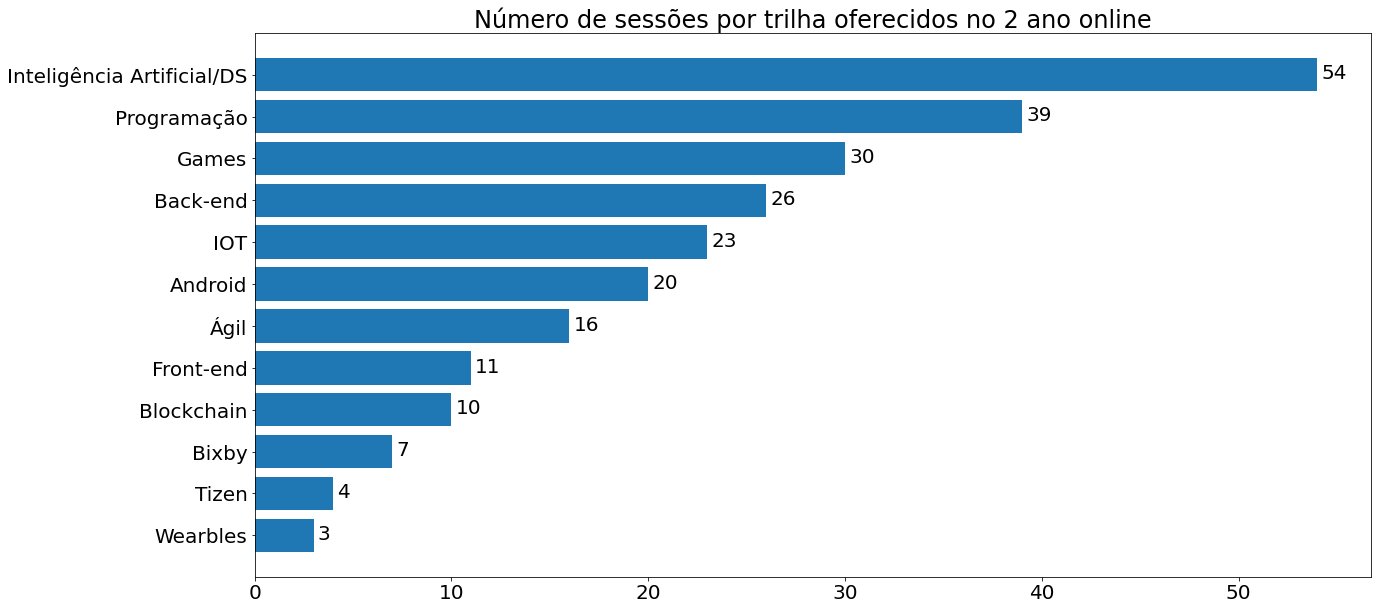

In [92]:
#plotando as informações em um gráfico 

#definindo variáveis dos eixos x e y
y_labels = []
x_values = [qtde for qtde in df_qtde_cursos_2_ano_online.qtde_cursos_2_ano]


#colocando nome da trilha completo em y_labels
for item in df_qtde_cursos_2_ano_online.eve_trilha:
        if item in trilhas_nome_completo.keys():
            y_labels.append(trilhas_nome_completo[item])

#definindo posições do eixo y
y_pos = np.arange(len(y_labels))
y_pos = y_pos[::-1]


#plot do gráfico 
fig,ax = plt.subplots(figsize=(20,10))
ax.barh(y_pos,width=df_qtde_cursos_2_ano_online.qtde_cursos_2_ano)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_title("Número de sessões por trilha oferecidos no 2 ano online")



for idx,txt in enumerate(x_values):
    ax.annotate(txt,(x_values[idx]+0.2,y_pos[idx]-0.1))

plt.rcParams.update({'font.size': 20})
plt.show()
#fig.savefig("numero_sessões_trilha_2_ano_online.png",bbox_inches="tight")

In [55]:
#separando nosso dataset por partes 
df_cursos_por_partes = search_word(df,"course_name","sessão|parte|tira")
df_cursos_por_partes["course_name"].unique()

array(['programandoparawebcompython,cssehtml(parte1)',
       'programandoparawebcompython,cssehtml(parte2)',
       'linguagempython:aprendendoalinguagem(parte1)',
       'linguagempython:aprendendoalinguagem(parte2)',
       'linguagempython:aprendendoalinguagem(parte3)',
       'introduçãoaodeeplearningcompythonekeras(parte1)',
       'introduçãoaodeeplearningcompythonekeras(parte2)',
       'webscrapingcompython(parte1)', 'webscrapingcompython(parte2)',
       'webscrapingcompython(parte3)',
       'ciênciadedados:visualizaçãodedadoscompython(parte1)',
       'ciênciadedados:visualizaçãodedadoscompython(parte2)',
       'jogosdigitais:jogo2dcomunity(parte1)',
       'jogosdigitais:jogo2dcomunity(parte2)',
       'introduçãoaanálisededadosgeográficoscompython(parte1)',
       'introduçãoaanálisededadosgeográficoscompython(parte2)',
       'introduçãoaanálisededadosgeográficoscompython(parte3)',
       'backendcomnodejseexpress(parte1)',
       'backendcomnodejseexpress(parte2)',
   

In [56]:
df_dados_repetidos = search_word(df,"course_name","sessão2|sessão02|parte2|parte02|parteII|sessão3|sessão03|parte03|parte3|parteIII|tira")
df_dados_repetidos["course_name"].unique()

array(['programandoparawebcompython,cssehtml(parte2)',
       'linguagempython:aprendendoalinguagem(parte2)',
       'linguagempython:aprendendoalinguagem(parte3)',
       'introduçãoaodeeplearningcompythonekeras(parte2)',
       'webscrapingcompython(parte2)', 'webscrapingcompython(parte3)',
       'ciênciadedados:visualizaçãodedadoscompython(parte2)',
       'jogosdigitais:jogo2dcomunity(parte2)',
       'introduçãoaanálisededadosgeográficoscompython(parte2)',
       'introduçãoaanálisededadosgeográficoscompython(parte3)',
       'backendcomnodejseexpress(parte2)',
       'consultandobasessqlcompython(parte2)',
       'introduçãoaofrontendwebcomreact(parte2)',
       'frontendwebcomreactjs:introdução(parte2)',
       'frontendwebcomreactjs-integraçãocombackend(parte2)',
       'oficinadejogos2dcomunity(parte2)',
       'oficinadejogos2dcomunity(parte3)',
       'deeplearning:introduçãocomkerasepython(parte2)',
       'programandoparawebcompython,cssehtml(parte3)',
       'jogosdigita

In [57]:
idx_dados_repetidos = df_dados_repetidos.index
idx_dados_repetidos

Int64Index([  6,  13,  14,  17,  25,  26,  29,  31,  33,  34,  40,  43,  44,
             47,  50,  52,  66,  68,  71,  77,  80,  82,  85,  98,  99, 101,
            103, 105, 106, 110, 112, 114, 116, 118, 120, 127, 129, 134, 137,
            139, 147, 151, 154, 160, 166, 167, 170, 172, 173, 178, 184, 186,
            200, 204, 206, 207, 208, 209, 210, 213, 217, 221, 222, 224, 226,
            231, 232, 235, 236, 245, 246, 248, 249],
           dtype='int64')

In [58]:
df_analise = df
df_analise.drop(idx_dados_repetidos,inplace=True)
df_analise["eve_title"].unique()

array(['Tizen: Ferramenta e Ambiente de Desenvolvimento',
       'Introdução a Análise de Dados Geográficos com Python',
       'Tizen: Desenvolvimento de aplicação para ambiente Tizen',
       'Introdução à Internet das Coisas',
       'Laboratório de IoT com Arduino',
       'Programando para web com Python, CSS e HTML (Parte 1)',
       'Desenvolvimento Ágil - DevOps Docker',
       'Desenvolvimento Ágil: DevOps GIT',
       'Introdução ao Backend com NodeJs e Express',
       'Laboratório de IoT com Raspberry Pi',
       'Laboratório de Backend com NodeJs e Express',
       'Linguagem Python: aprendendo a linguagem (Parte1)',
       'Introdução ao Frontend Web com React',
       'Introdução ao Deep Learning com Python e Keras (Parte 1)',
       'Palestra: Assistente Virtual de Voz em Bixby - Trazendo Inteligência à Interface',
       'Integrando os serviços de backend na nuvem',
       'Laboratório de Frontend Web com React',
       'Mineração de Opinião com Python', 'Android: Intr

In [59]:
#agrupando os dados por trilha
qtde_cursos_por_trilha = df_analise.groupby(["eve_trilha"]).size().sort_values(ascending=False)
df_qtde_cursos_por_trilha = pd.DataFrame({"eve_trilha":qtde_cursos_por_trilha.index,"qtde_cursos_trilha":qtde_cursos_por_trilha.values})
df_qtde_cursos_por_trilha

,eve_trilha,qtde_cursos_trilha
0,IAR,34
1,IOT,21
2,AND,20
3,GME,20
4,BCKEND,19
5,PRG,16
6,ÁGIL,14
7,BLC,10
8,BXB,7
9,FRTEND,6


In [60]:
df_qtde_cursos_por_trilha_online = df_qtde_cursos_por_trilha.loc[df_qtde_cursos_por_trilha.eve_trilha!="FABLAB"]
df_qtde_cursos_por_trilha_online

,eve_trilha,qtde_cursos_trilha
0,IAR,34
1,IOT,21
2,AND,20
3,GME,20
4,BCKEND,19
5,PRG,16
6,ÁGIL,14
7,BLC,10
8,BXB,7
9,FRTEND,6


In [61]:
total_modulos_trilha = sum(df_qtde_cursos_por_trilha_online.qtde_cursos_trilha)
print(f"Total de quantidade de modulos por trilha é: {total_modulos_trilha}")

Total de quantidade de modulos por trilha é: 174


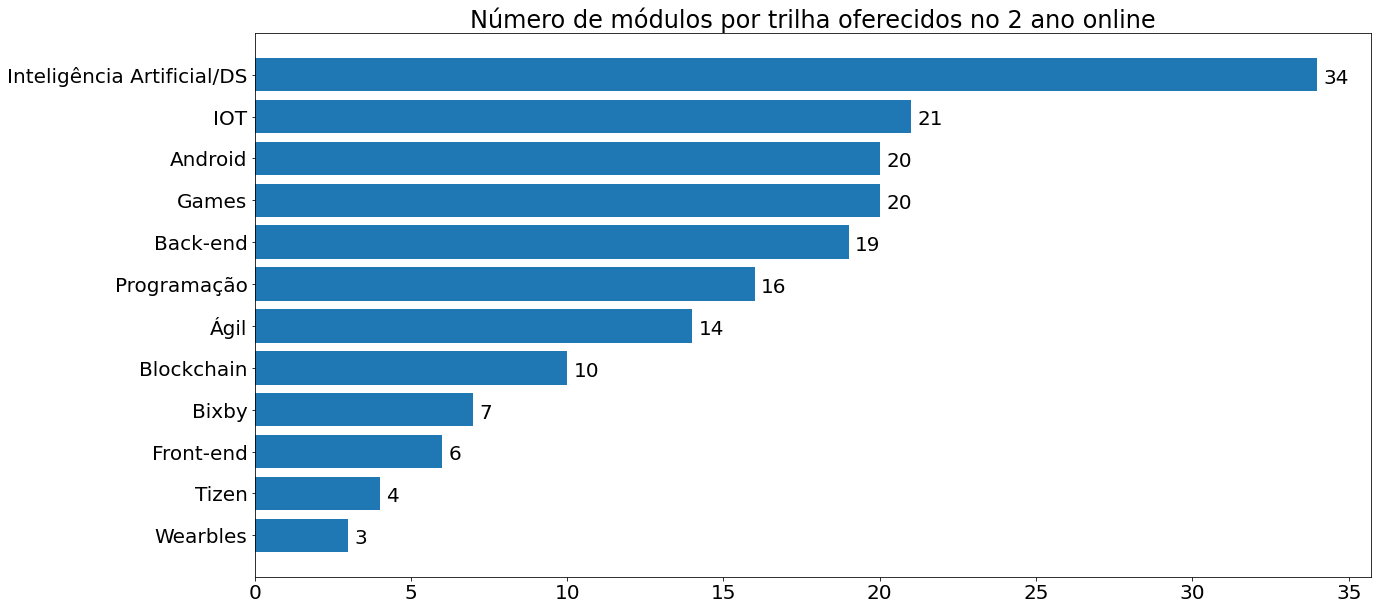

In [91]:
#plotando as informações em um gráfico 

#definindo variáveis de x e y 
y_labels = []
x_values = [qtde for qtde in df_qtde_cursos_por_trilha_online.qtde_cursos_trilha]

for item in df_qtde_cursos_por_trilha_online.eve_trilha:
    if item in trilhas_nome_completo.keys():
        y_labels.append(trilhas_nome_completo[item])

y_pos = np.arange(len(y_labels))
y_pos = y_pos[::-1]

#plot do gráfico
fig,ax = plt.subplots(figsize=(20,10))
ax.barh(y_pos,width=df_qtde_cursos_por_trilha_online.qtde_cursos_trilha,label=y_labels)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_title("Número de módulos por trilha oferecidos no 2 ano online")


for idx,txt in enumerate(x_values):
    ax.annotate(txt,(x_values[idx]+0.2,y_pos[idx]-0.2))

plt.rcParams.update({'font.size': 20})
#fig.savefig("Número de módulos por trilha oferecidos no 2 ano online",bbox_inches="tight")
plt.show()

Horas por trilha

In [71]:
#convertando os dados de hora para float 
#lembre-se de rodar a celula de df de novo ao chegar aqui (e remover duplicadas)
def convert_float(column):
    for idx in range(len(column)) :
        if isinstance(column[idx],str):
           h,m = column[idx].split(":")
           h = float(h)
           m = float(m)/60
           column[idx] = float(h+m)
    return column

In [72]:
#mudando tipo de variáveis de eve_workload
df["eve_workload"] = convert_float(df["eve_workload"])
df["eve_workload"] = df["eve_workload"].astype("float32")

<ipython-input-71-e1290247ad29>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column[idx] = float(h+m)


In [73]:
#somando a quantidade de hora por trilha 
qtde_hr_trilha= df.groupby(["eve_trilha"])["eve_workload"].sum()
df_qtde_hr_trilha_online = pd.DataFrame({"eve_trilha":qtde_hr_trilha.index,"eve_workload":qtde_hr_trilha.values})
df_qtde_hr_trilha_online = df_qtde_hr_trilha_online.loc[df_qtde_hr_trilha_online.eve_trilha !="FABLAB"]
df_qtde_hr_trilha_online = df_qtde_hr_trilha_online.sort_values(ascending=False,by="eve_workload",ignore_index=True)
df_qtde_hr_trilha_online

,eve_trilha,eve_workload
0,IAR,138.0
1,PRG,117.0
2,BCKEND,78.0
3,GME,70.0
4,IOT,61.0
5,AND,60.0
6,ÁGIL,43.0
7,FRTEND,33.0
8,BLC,23.0
9,BXB,14.0


In [74]:
total_horas_trilha = sum(df_qtde_hr_trilha_online.eve_workload)
print(f"Total de quantidade de horas por trilha é: {total_horas_trilha}")

Total de quantidade de horas por trilha é: 648.5


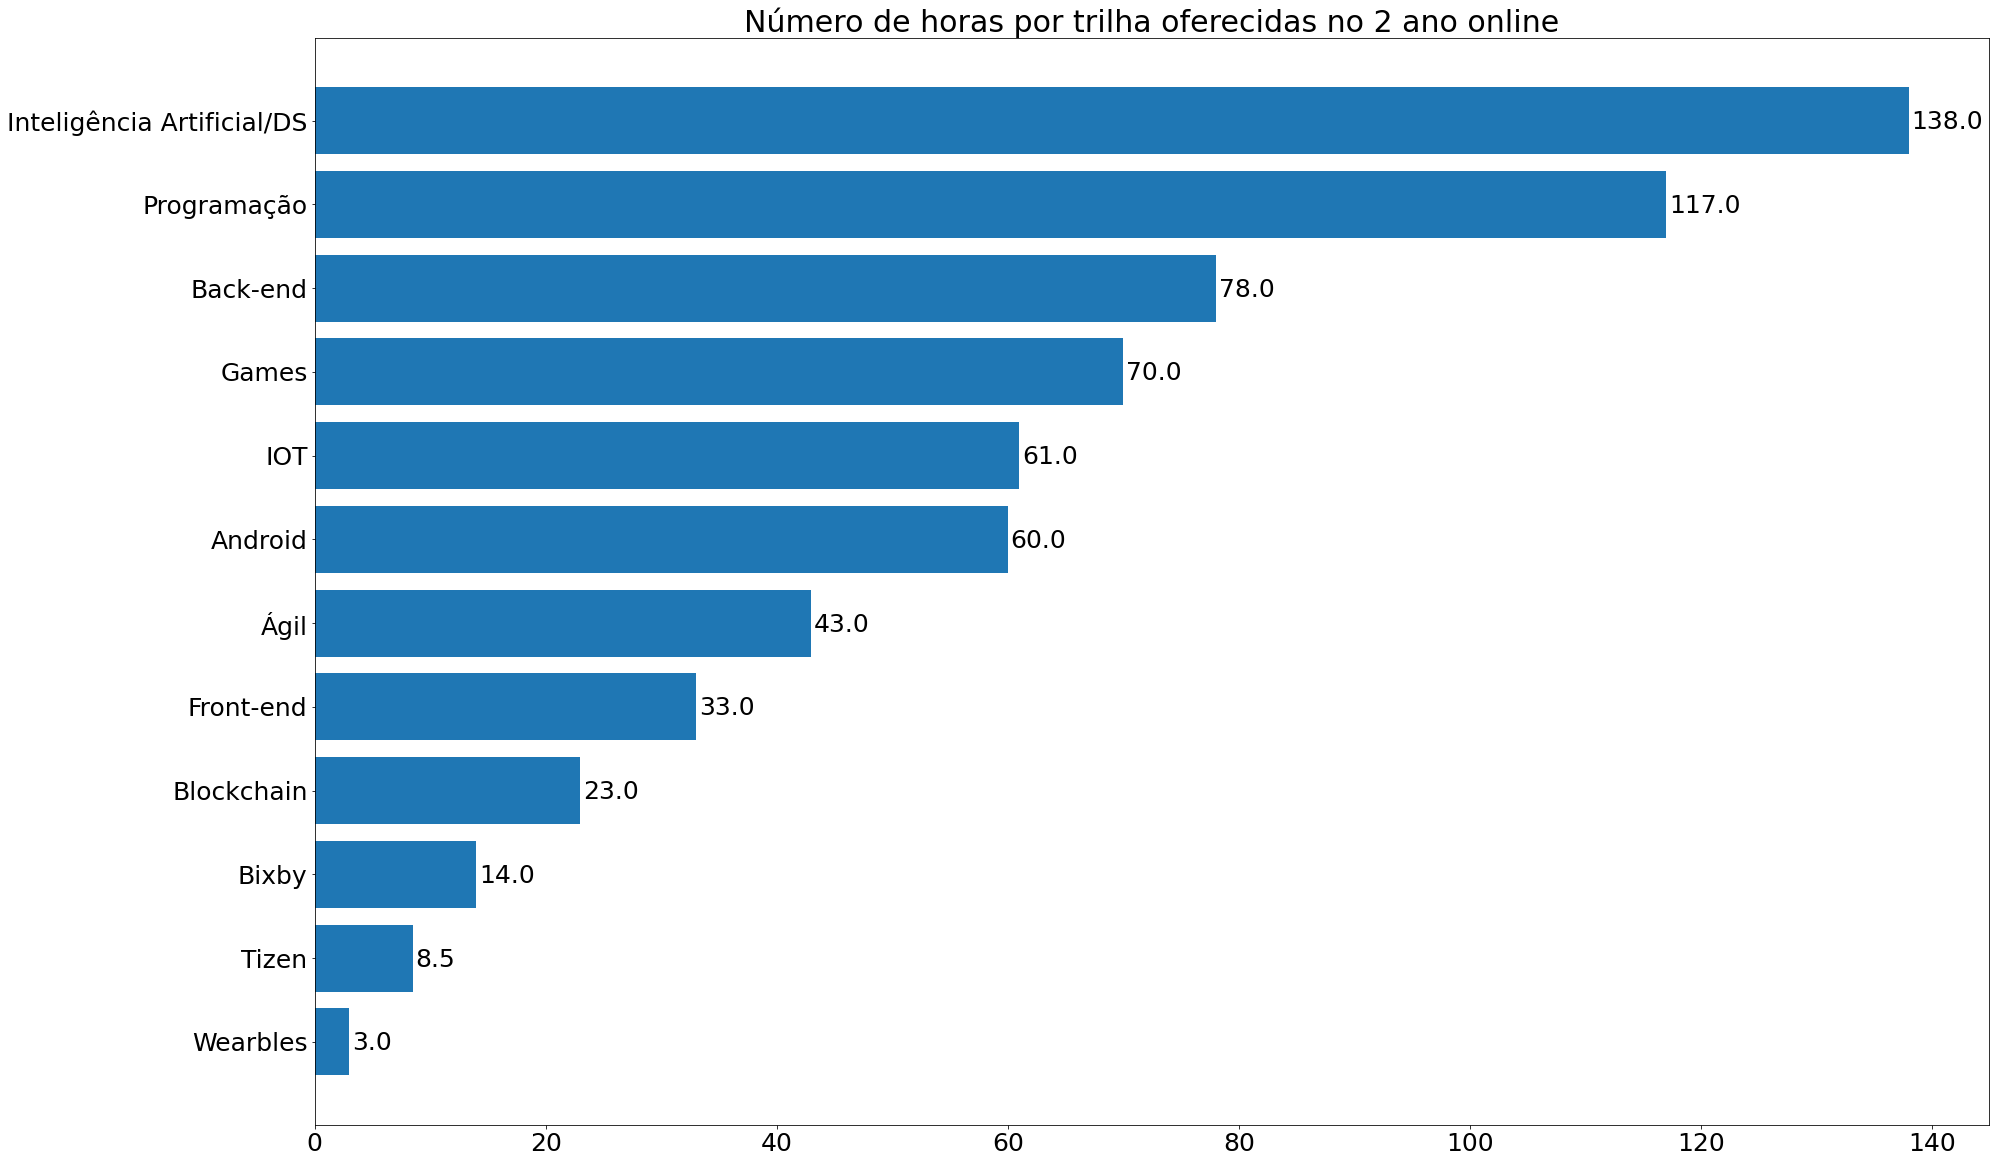

In [86]:
#plotando as informações em um gráfico 

#definindo variáveis para os eixos x e y
y_labels  = []
x_values = [hr for hr in df_qtde_hr_trilha_online.eve_workload]


for item in df_qtde_hr_trilha_online.eve_trilha:
        if item in trilhas_nome_completo.keys():
            y_labels.append(trilhas_nome_completo[item])
            
y_pos = np.arange(len(y_labels))
y_pos = y_pos[::-1]

#plot do gráfico 
fig,ax = plt.subplots(figsize=(30,20))
ax.barh(y_pos,width=df_qtde_hr_trilha_online.eve_workload,label=y_labels)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_title("Número de horas por trilha oferecidas no 2 ano online")
#rect = matplotlib.patches.Rectangle((60,20),10,10,linewidth=1, edgecolor='r', facecolor='none')
#ax.add_patch(rect)

for idx,txt in enumerate(x_values):
    ax.annotate(txt,(x_values[idx]+0.25,y_pos[idx]-0.1))

plt.rcParams.update({'font.size': 25})   
plt.show()
#fig.savefig("número_horas_trilha_2_ano_online.png",bbox_inches="tight")